**LINEAR REGRESSION HOUSE PRICE PREDICTION MINI PROJECT**

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

data = {
    "Area_sqft": np.random.randint(500, 3000, n),
    "Bedrooms": np.random.randint(1, 6, n),
    "Bathrooms": np.random.randint(1, 5, n),
    "Age": np.random.randint(0, 30, n),
    "Location_Score": np.random.randint(1, 11, n),
    "Garage": np.random.randint(0, 2, n),
}

df = pd.DataFrame(data)

df["Price"] = (
    df["Area_sqft"] * 5000 +
    df["Bedrooms"] * 300000 +
    df["Bathrooms"] * 200000 +
    df["Location_Score"] * 500000 -
    df["Age"] * 100000 +
    df["Garage"] * 250000 +
    np.random.randint(-500000, 500000, n)
)

df.to_csv("house_prices.csv", index=False)

print(df.head())

   Area_sqft  Bedrooms  Bathrooms  Age  Location_Score  Garage     Price
0       1360         1          2   15               6       1   9228928
1       1794         4          2   10               7       0  12698447
2       1630         5          2    4               9       0  14111693
3       1595         1          3    3               3       0   9580695
4       2138         1          4   29               2       1  10203457


In [2]:
# now we have a dataset of 1000 house listings with various features and their corresponding prices.and we are taking the features and target variable for training a machine learning model to predict house prices based on the given features.
X=df.drop("Price",axis=1)
y=df["Price"]


In [3]:
from sklearn.model_selection import train_test_split
# Splitting the dataset into training and testing sets with an 80-20 split and a random state for reproducibility.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Now we have our training and testing datasets ready for building and evaluating our machine learning model.
# what it is doing?
# It splits the data into training and testing sets, where 80% is used for training and 20% for testing.
# The random_state parameter ensures that the split is reproducible, meaning you will get the same split every time you run the code.

In [4]:
# now we compute the cost function for linear regression, which is the mean squared error between the predicted values and the actual values of the target variable (house prices). The cost function helps us evaluate how well our model is performing and guides us in optimizing the model parameters to minimize the error.

def cost_function(X,y,w,b):
    # w is ndarray of shape (n_features,)
    # b is scalar
    m=X.shape[0]#number of training examples
    total_cost=0
    for i in range(m):
        f_wb=np.dot(X[i],w)+b
        c=(f_wb-y[i])**2
        total_cost+=c
    return total_cost/(2*m)



In [5]:
# now we will implement the gradient descent but first we will compute the gradients of the cost function with respect to the parameters w and b. The gradients indicate the direction and magnitude of the steepest ascent in the cost function, which we will use to update our parameters in the opposite direction to minimize the cost.
def compute_gradient(X,y,w,b):
    m=X.shape[0] #number of training examples
    m=X.shape[1] #number of features of the dataset
    dj_dw=np.zeros(n)
    dj_db=0
    for i in range(m):
        f_wb=np.dot(X[i],w)+b
        err=f_wb-y[i]
        for j in range(n):
            dj_dw+=err*X[i][j]
        dj_db+=err
    dj_dw/=m
    dj_db/=m
    return dj_dw,dj_db

In [6]:
X_train=X.values
y_train=y.values

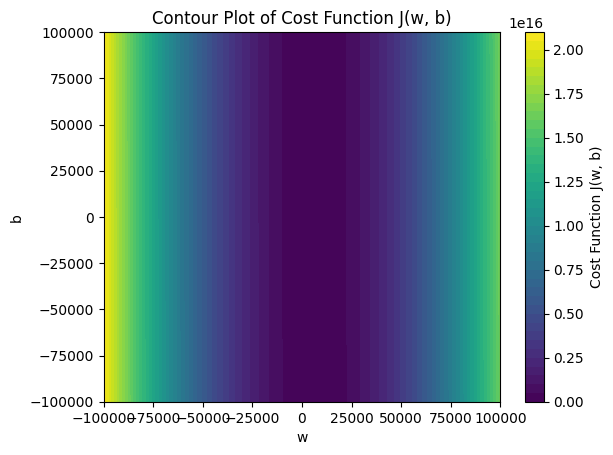

In [7]:
# visualizing the cost function w is ndarray and b is scalar and J is the cost function value for each combination of w and b. The contour plot helps us understand how the cost function changes with different values of w and b, and it can guide us in finding the optimal parameters that minimize the cost.

import matplotlib.pyplot as plt # w has size only 6 because we have 6 features in our dataset and b is a scalar parameter that represents the bias term in our linear regression model. The cost function J is computed for each combination of w and b, and the contour plot visualizes how the cost function changes with different values of w and b, helping us understand the optimization landscape of our model.
# just take w as 6 sized and b is scalar
w = np.random.randn(6)   # if 6 features

b = np.random.randn()   # scalar bias term
w_values = np.linspace(-100000, 100000, 100)
b_values = np.linspace(-100000, 100000, 100)
J_values = np.zeros((len(w_values), len(b_values)))
for i in range(len(w_values)):
    for j in range(len(b_values)):
        w_temp = np.full_like(w, w_values[i])  # Create a temporary w with the same value for all features
        b_temp = b_values[j]
        J_values[i, j] = cost_function(X_train, y_train, w_temp, b_temp)
W, B = np.meshgrid(w_values, b_values)
plt.contourf(W, B, J_values.T, levels=50, cmap='viridis')
plt.colorbar(label='Cost Function J(w, b)')
plt.xlabel('w')
plt.ylabel('b')
plt.title('Contour Plot of Cost Function J(w, b)')
plt.show()





In [8]:
# Now we can proceed to make our gradient descent algorithm to find the optimal parametes w,b that minimixe the cost function.
def gradient_descent(X,y,w,b,alpha,num_iters):
    for i in range(num_iters):
        dj_dw,dj_db=compute_gradient(X,y,w,b)
        w=w-alpha*dj_dw
        b=b-alpha*dj_db
    return w,b

In [9]:
print(w)

[-1.24552059 -0.72994095 -1.10661941  0.57282101 -1.06331248 -0.71424611]
